<a href="https://colab.research.google.com/github/deepshikha04yadav/Text-to-Image/blob/main/conditional_gan_nb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CONDITIONAL GAN NOTEBOOK
Demonstrates conditional inputs in GANs with shape generation

In [5]:
# Setup and Imports

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import os
from tqdm import tqdm
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")

 Device: cuda


In [6]:
!git clone https://github.com/deepshikha04yadav/Text-to-Image

fatal: destination path 'Text-to-Image' already exists and is not an empty directory.


In [ ]:
# Load CGAN System

# Load the complete CGAN system
%run conditional_gan_shapes.py

print(" CGAN system loaded")

VISUALIZING DATASET SAMPLES
📊 ShapeDataset initialized:
   Samples: 1000
   Image size: 64x64
   Shapes (6): circle, square, triangle, star, diamond, hexagon
💾 Saved: dataset_samples.png


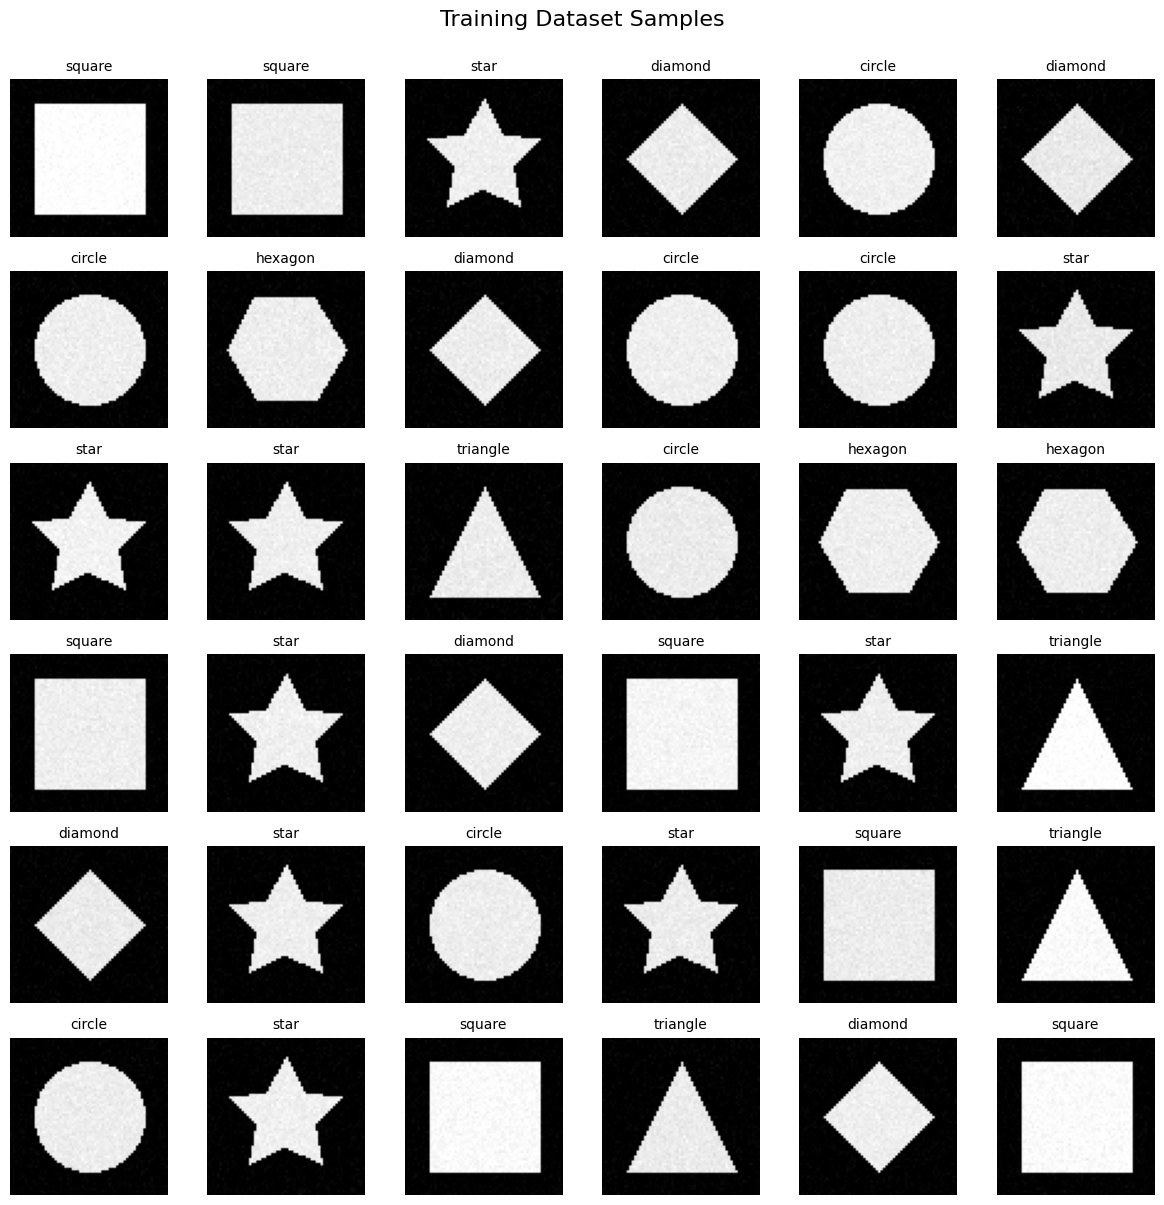

In [8]:
# Visualize Dataset Samples

print("=" * 80)
print("VISUALIZING DATASET SAMPLES")
print("=" * 80)

# Create dataset
dataset = ShapeDataset(num_samples=1000, size=64)

# Visualize samples
fig, axes = plt.subplots(6, 6, figsize=(12, 12))
axes = axes.flatten()

for i in range(36):
    sample = dataset[i]
    img = sample['image'][0].numpy()
    shape_name = sample['shape_name']

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(shape_name, fontsize=10)
    axes[i].axis('off')

plt.suptitle('Training Dataset Samples', fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig('dataset_samples.png', dpi=150, bbox_inches='tight')
print(" Saved: dataset_samples.png")
plt.show()

In [ ]:
# Initialize and Train CGAN

print("\n" + "=" * 80)
print("TRAINING CONDITIONAL GAN")
print("=" * 80)

# Configuration
BATCH_SIZE = 64
NUM_EPOCHS = 50  # Increase for better quality
IMAGE_SIZE = 64
LATENT_DIM = 100
NUM_CLASSES = 6

print(f"\n  Configuration:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"   Shapes: {NUM_CLASSES}")

# Create dataset and dataloader
dataset = ShapeDataset(num_samples=10000, size=IMAGE_SIZE)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# Create models
generator = ConditionalGenerator(
    latent_dim=LATENT_DIM,
    num_classes=NUM_CLASSES,
    image_size=IMAGE_SIZE
).to(device)

discriminator = ConditionalDiscriminator(
    num_classes=NUM_CLASSES,
    image_size=IMAGE_SIZE
).to(device)

print(f"\n Model Statistics:")
print(f"   Generator: {sum(p.numel() for p in generator.parameters()):,} params")
print(f"   Discriminator: {sum(p.numel() for p in discriminator.parameters()):,} params")

# Create trainer
trainer = CGANTrainer(generator, discriminator, device=device)

# Train
print(f"\n Starting training...")
trainer.train(dataloader, num_epochs=NUM_EPOCHS, save_dir='./outputs/cgan')

print("\n Training complete!")


GENERATING SPECIFIC SHAPES
Generating circle...
Generating square...
Generating triangle...
Generating star...
Generating diamond...
Generating hexagon...

💾 Saved: generated_shapes.png


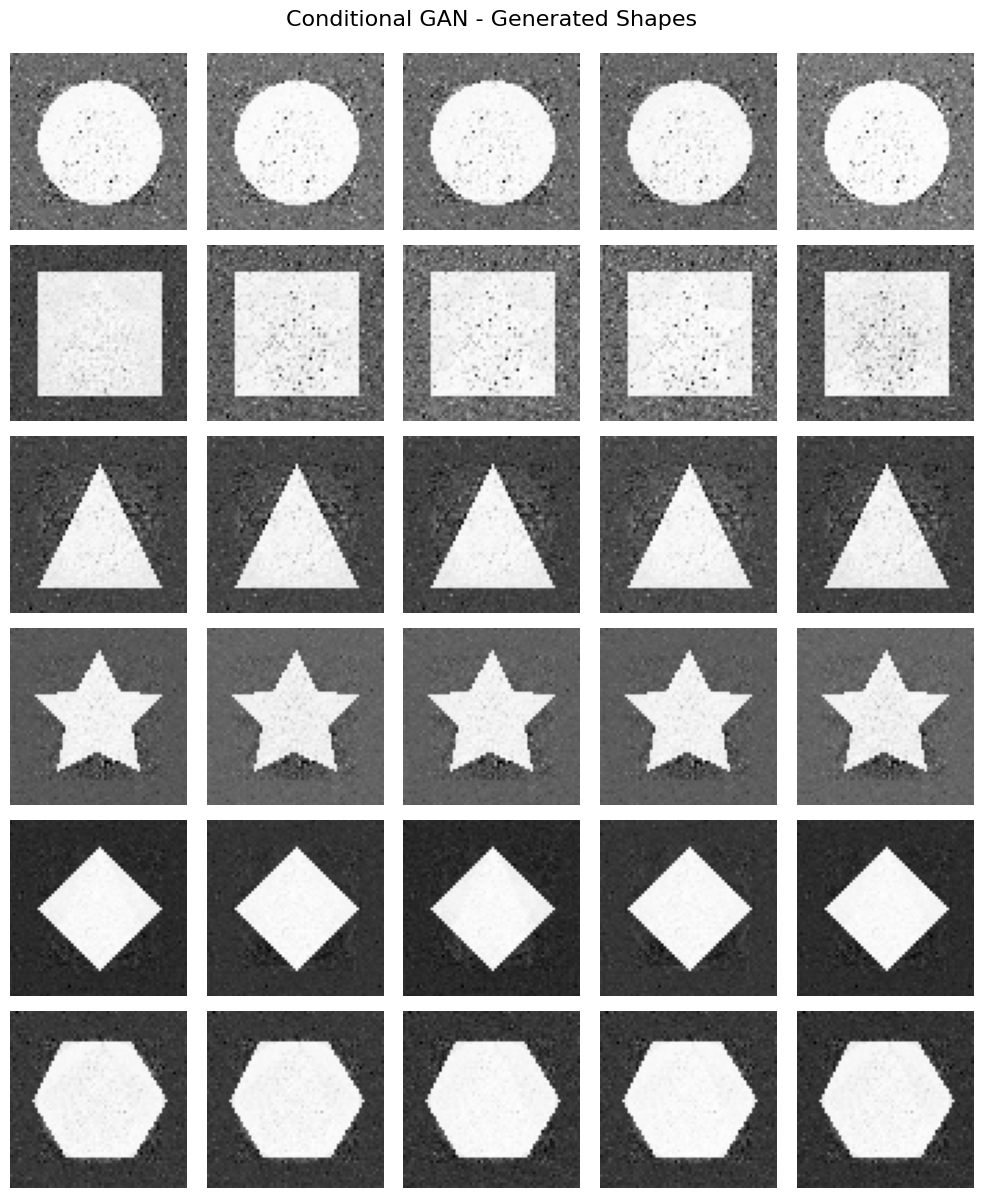

In [10]:
# Generate Specific Shapes

print("\n" + "=" * 80)
print("GENERATING SPECIFIC SHAPES")
print("=" * 80)

# Generate samples for each shape
shapes = ['circle', 'square', 'triangle', 'star', 'diamond', 'hexagon']
num_samples = 5

fig, axes = plt.subplots(len(shapes), num_samples, figsize=(num_samples*2, len(shapes)*2))

generator.eval()

with torch.no_grad():
    for i, shape in enumerate(shapes):
        shape_idx = i

        print(f"Generating {shape}...")

        for j in range(num_samples):
            # Generate
            noise = torch.randn(1, LATENT_DIM, device=device)
            label = torch.tensor([shape_idx], device=device)

            generated = generator(noise, label)

            # Convert to image
            img = generated[0, 0].cpu().numpy()
            img = (img + 1) / 2  # [-1, 1] → [0, 1]

            # Plot
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')

            if j == 0:
                axes[i, j].set_ylabel(shape, fontsize=12, rotation=0,
                                     ha='right', va='center')

plt.suptitle('Conditional GAN - Generated Shapes', fontsize=16, y=0.995)
plt.tight_layout()
plt.savefig('generated_shapes.png', dpi=150, bbox_inches='tight')
print("\n Saved: generated_shapes.png")
plt.show()


INTERACTIVE SHAPE GENERATION

🎨 Generating circles...


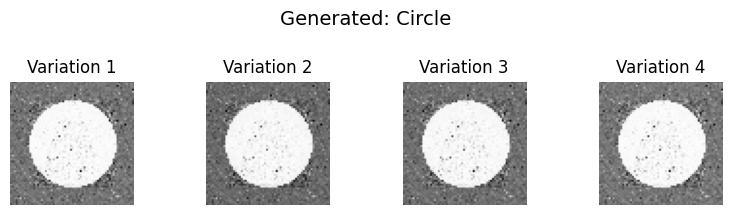


🎨 Generating stars...


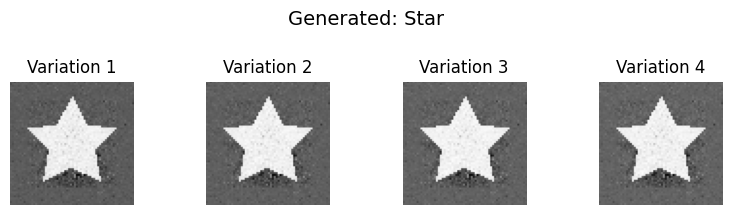


🎨 Generating triangles...


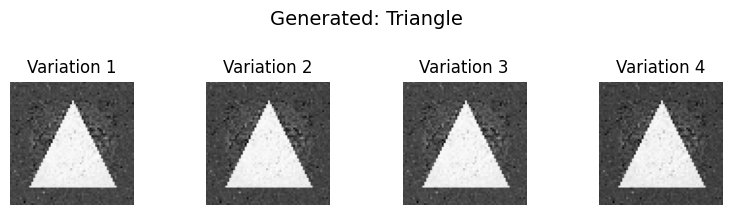

In [11]:
# Interactive Shape Generation

print("\n" + "=" * 80)
print("INTERACTIVE SHAPE GENERATION")
print("=" * 80)

def generate_shape_interactive(shape_name, num_variations=4):
    """Generate shape with variations"""
    shapes_dict = {
        'circle': 0,
        'square': 1,
        'triangle': 2,
        'star': 3,
        'diamond': 4,
        'hexagon': 5
    }

    if shape_name.lower() not in shapes_dict:
        print(f" Unknown shape. Available: {list(shapes_dict.keys())}")
        return

    shape_idx = shapes_dict[shape_name.lower()]

    fig, axes = plt.subplots(1, num_variations, figsize=(num_variations*2, 2))

    generator.eval()

    with torch.no_grad():
        for i in range(num_variations):
            noise = torch.randn(1, LATENT_DIM, device=device)
            label = torch.tensor([shape_idx], device=device)

            generated = generator(noise, label)

            img = generated[0, 0].cpu().numpy()
            img = (img + 1) / 2

            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(f"Variation {i+1}")
            axes[i].axis('off')

    plt.suptitle(f"Generated: {shape_name.title()}", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

# Generate different shapes
print("\n Generating circles...")
generate_shape_interactive('circle', 4)

print("\n Generating stars...")
generate_shape_interactive('star', 4)

print("\n Generating triangles...")
generate_shape_interactive('triangle', 4)


DEMONSTRATING CONDITIONING EFFECT

💡 Key Concept: Conditional GANs

The same noise vector + different labels = different shapes!
This proves the generator learned to condition on the label.


Using SAME noise for all shapes:
💾 Saved: conditioning_effect.png


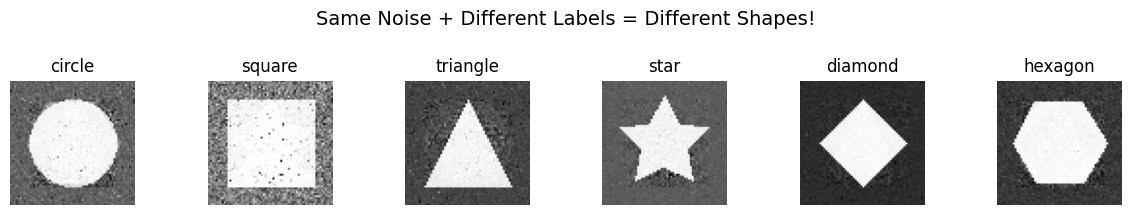


✅ This demonstrates successful conditioning!


In [12]:
# Demonstrate Conditioning Effect

print("\n" + "=" * 80)
print("DEMONSTRATING CONDITIONING EFFECT")
print("=" * 80)

print("""
💡 Key Concept: Conditional GANs

The same noise vector + different labels = different shapes!
This proves the generator learned to condition on the label.
""")

# Fixed noise, varying labels
print("\nUsing SAME noise for all shapes:")

fixed_noise = torch.randn(1, LATENT_DIM, device=device)

fig, axes = plt.subplots(1, 6, figsize=(12, 2))

generator.eval()

with torch.no_grad():
    for i, shape in enumerate(shapes):
        label = torch.tensor([i], device=device)

        # Same noise, different label!
        generated = generator(fixed_noise, label)

        img = generated[0, 0].cpu().numpy()
        img = (img + 1) / 2

        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(shape, fontsize=12)
        axes[i].axis('off')

plt.suptitle('Same Noise + Different Labels = Different Shapes!',
             fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig('conditioning_effect.png', dpi=150, bbox_inches='tight')
print(" Saved: conditioning_effect.png")
plt.show()

print("\n This demonstrates successful conditioning!")


UNCONDITIONAL vs CONDITIONAL COMPARISON

📊 Comparison:

UNCONDITIONAL GAN:
   Input: noise → Output: random image
   Problem: Cannot control what is generated

CONDITIONAL GAN:
   Input: noise + label → Output: specific shape
   Advantage: Full control over output!


Row 1: Random labels (like unconditional)
Row 2: All circles (conditional control)
💾 Saved: conditional_advantage.png


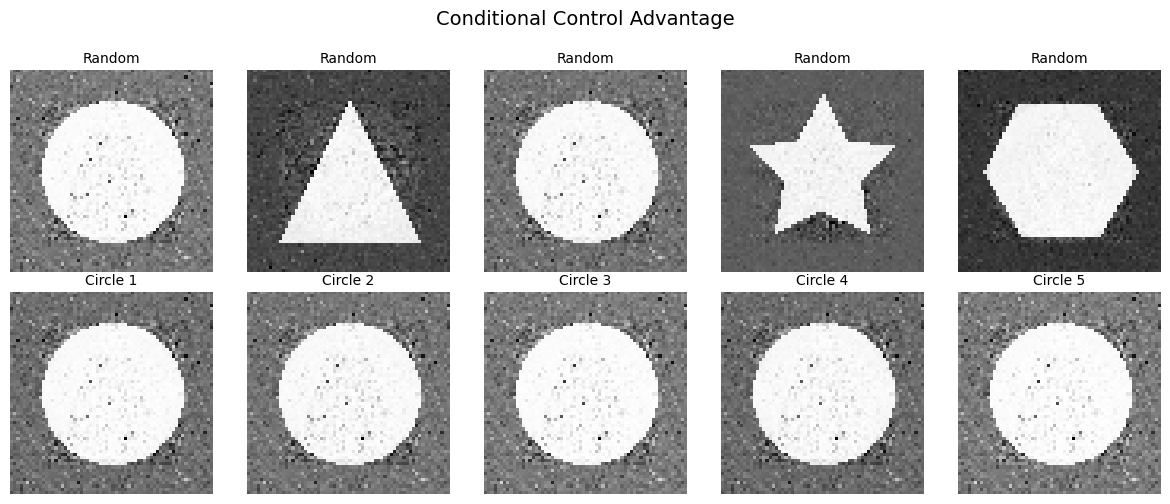

In [13]:
# Test Unconditional vs Conditional

print("\n" + "=" * 80)
print("UNCONDITIONAL vs CONDITIONAL COMPARISON")
print("=" * 80)

print("""
 Comparison:

UNCONDITIONAL GAN:
   Input: noise → Output: random image
   Problem: Cannot control what is generated

CONDITIONAL GAN:
   Input: noise + label → Output: specific shape
   Advantage: Full control over output!
""")

# Visualize the difference
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

generator.eval()

# Row 1: Random labels (simulating unconditional)
print("\nRow 1: Random labels (like unconditional)")
with torch.no_grad():
    for i in range(5):
        noise = torch.randn(1, LATENT_DIM, device=device)
        label = torch.tensor([random.randint(0, 5)], device=device)

        generated = generator(noise, label)
        img = generated[0, 0].cpu().numpy()
        img = (img + 1) / 2

        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f"Random", fontsize=10)
        axes[0, i].axis('off')

# Row 2: All circles (conditional control)
print("Row 2: All circles (conditional control)")
with torch.no_grad():
    for i in range(5):
        noise = torch.randn(1, LATENT_DIM, device=device)
        label = torch.tensor([0], device=device)  # Circle

        generated = generator(noise, label)
        img = generated[0, 0].cpu().numpy()
        img = (img + 1) / 2

        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(f"Circle {i+1}", fontsize=10)
        axes[1, i].axis('off')

axes[0, 0].set_ylabel("Uncontrolled", fontsize=12, rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel("Controlled", fontsize=12, rotation=0, ha='right', va='center')

plt.suptitle('Conditional Control Advantage', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('conditional_advantage.png', dpi=150, bbox_inches='tight')
print(" Saved: conditional_advantage.png")
plt.show()


SAVING AND LOADING MODEL
💾 Model saved: ./outputs/cgan/checkpoints/cgan_final.pt

📂 Loading model...
✅ Model loaded successfully!

Testing loaded model:


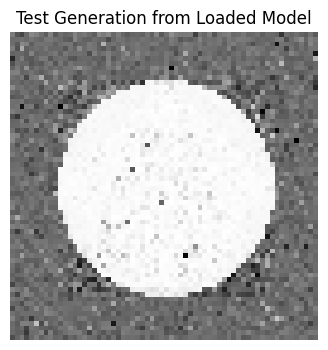

In [14]:
# Save and Load Model

print("\n" + "=" * 80)
print("SAVING AND LOADING MODEL")
print("=" * 80)

# Save trained model
save_path = './outputs/cgan/checkpoints/cgan_final.pt'

checkpoint = {
    'generator': generator.state_dict(),
    'discriminator': discriminator.state_dict(),
    'shapes': shapes,
    'config': {
        'latent_dim': LATENT_DIM,
        'num_classes': NUM_CLASSES,
        'image_size': IMAGE_SIZE
    }
}

torch.save(checkpoint, save_path)
print(f" Model saved: {save_path}")

# Load model
print(f"\n Loading model...")
loaded_checkpoint = torch.load(save_path)

new_generator = ConditionalGenerator(
    latent_dim=LATENT_DIM,
    num_classes=NUM_CLASSES,
    image_size=IMAGE_SIZE
).to(device)

new_generator.load_state_dict(loaded_checkpoint['generator'])
new_generator.eval()

print(f" Model loaded successfully!")

# Test loaded model
print(f"\nTesting loaded model:")
with torch.no_grad():
    noise = torch.randn(1, LATENT_DIM, device=device)
    label = torch.tensor([0], device=device)  # Circle

    generated = new_generator(noise, label)
    img = generated[0, 0].cpu().numpy()
    img = (img + 1) / 2

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title('Test Generation from Loaded Model')
    plt.axis('off')
    plt.show()



In [15]:
# Understanding Conditional Inputs

print("\n" + "=" * 80)
print("UNDERSTANDING CONDITIONAL INPUTS IN GANs")
print("=" * 80)

print("""
 CONDITIONAL GAN ARCHITECTURE:

1. GENERATOR:
   Input:  Noise (100-dim) + Label Embedding (50-dim) = 150-dim
   Output: Image (64x64)

   Flow:
   ┌──────────┐     ┌─────────────────┐     ┌────────┐
   │  Noise   │ ──> │   Concatenate   │ ──> │  MLP   │ ──> Image
   └──────────┘     │  with Label     │     └────────┘
   ┌──────────┐     │   Embedding     │
   │  Label   │ ──> └─────────────────┘
   └──────────┘

2. DISCRIMINATOR:
   Input:  Image (flattened) + Label Embedding = Combined features
   Output: Real/Fake probability

   Flow:
   ┌──────────┐     ┌─────────────────┐     ┌────────┐
   │  Image   │ ──> │   Concatenate   │ ──> │  MLP   │ ──> Real/Fake
   └──────────┘     │  with Label     │     └────────┘
   ┌──────────┐     │   Embedding     │
   │  Label   │ ──> └─────────────────┘

 KEY INSIGHT:
   Both Generator and Discriminator receive the label!
   - Generator learns to produce the requested shape
   - Discriminator learns to check if shape matches label

 BENEFITS:
   ✓ Controlled generation
   ✓ Can generate specific classes
   ✓ More stable training
   ✓ Higher quality outputs
   ✓ Useful for real applications

 REAL-WORLD APPLICATIONS:
   • Generate faces with specific attributes (age, gender, etc.)
   • Create images of specific objects (cars, buildings, etc.)
   • Synthesize data for specific classes (medical imaging)
   • Style transfer with condition on style
   • Text-to-image (text as condition)
""")


UNDERSTANDING CONDITIONAL INPUTS IN GANs

📚 CONDITIONAL GAN ARCHITECTURE:

1. GENERATOR:
   Input:  Noise (100-dim) + Label Embedding (50-dim) = 150-dim
   Output: Image (64x64)

   Flow:
   ┌──────────┐     ┌─────────────────┐     ┌────────┐
   │  Noise   │ ──> │   Concatenate   │ ──> │  MLP   │ ──> Image
   └──────────┘     │  with Label     │     └────────┘
   ┌──────────┐     │   Embedding     │
   │  Label   │ ──> └─────────────────┘
   └──────────┘

2. DISCRIMINATOR:
   Input:  Image (flattened) + Label Embedding = Combined features
   Output: Real/Fake probability

   Flow:
   ┌──────────┐     ┌─────────────────┐     ┌────────┐
   │  Image   │ ──> │   Concatenate   │ ──> │  MLP   │ ──> Real/Fake
   └──────────┘     │  with Label     │     └────────┘
   ┌──────────┐     │   Embedding     │
   │  Label   │ ──> └─────────────────┘

💡 KEY INSIGHT:
   Both Generator and Discriminator receive the label!
   - Generator learns to produce the requested shape
   - Discriminator learns to

In [16]:
# SUMMARY

print("\n" + "=" * 80)
print(" CONDITIONAL GAN - COMPLETE!")
print("=" * 80)

print("""
 What You Learned:

1. ✓ Conditional GANs use labels to control generation
2. ✓ Generator receives noise + label → specific output
3. ✓ Discriminator checks image + label → real/fake
4. ✓ Same noise + different labels = different outputs
5. ✓ Perfect for controlled generation tasks

 Key Advantages:

• CONTROL: Generate exactly what you want
• QUALITY: Better convergence than unconditional
• VERSATILITY: Works with any type of label
• SCALABILITY: Easy to add more classes

 Files Generated:

• dataset_samples.png - Training data visualization
• generated_shapes.png - All shape types
• conditioning_effect.png - Demonstrates conditioning
• conditional_advantage.png - Shows control benefit
• Model checkpoint in ./outputs/cgan/checkpoints/

 Next Steps:

1. Try with more complex shapes
2. Increase image resolution
3. Add color conditioning
4. Apply to real datasets (MNIST, CIFAR-10)
5. Extend to text-to-image (like your main GAN!)

 The same principle applies to your text-to-image GAN:
   Text embedding = Condition
   Generator uses text to guide image creation
   Discriminator checks if image matches text
""")

print("\n" + "=" * 80)
print("Happy Generating! ")
print("=" * 80)


✅ CONDITIONAL GAN - COMPLETE!

📊 What You Learned:

1. ✓ Conditional GANs use labels to control generation
2. ✓ Generator receives noise + label → specific output
3. ✓ Discriminator checks image + label → real/fake
4. ✓ Same noise + different labels = different outputs
5. ✓ Perfect for controlled generation tasks

🎯 Key Advantages:

• CONTROL: Generate exactly what you want
• QUALITY: Better convergence than unconditional
• VERSATILITY: Works with any type of label
• SCALABILITY: Easy to add more classes

📁 Files Generated:

• dataset_samples.png - Training data visualization
• generated_shapes.png - All shape types
• conditioning_effect.png - Demonstrates conditioning
• conditional_advantage.png - Shows control benefit
• Model checkpoint in ./outputs/cgan/checkpoints/

🚀 Next Steps:

1. Try with more complex shapes
2. Increase image resolution
3. Add color conditioning
4. Apply to real datasets (MNIST, CIFAR-10)
5. Extend to text-to-image (like your main GAN!)

💡 The same principle a